# Notebook to define and evaluate a baseline Siamese U-Net

Note that U-Net baseline uses early fusion whereas Siamese uses late fusion via feature differencing. In other words, these two architectures differ in how input data is fused, and evaluation of these architectures must consider these differences.

## Set up

In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("CWD:", os.getcwd())
print("Project root added:", project_root)

CWD: c:\Dev\Damage_Assessment_on_xBD\Model_Architectures Notebooks
Project root added: c:\Dev\Damage_Assessment_on_xBD


In [2]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from src.model_siamese import SiameseUNet
from src.visualizations import visualize_predictions

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4070


In [4]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 8
LR = 1e-4
NUM_EPOCHS = 50
PATIENCE = 12
BASE_FEATURES = 32
SAVE_PATH = "best_siamese_unet_combo.pth"

In [5]:
# Create Data Splits
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from Preprocessing.xBD_splits import create_splits
img_dir = r"..\Preprocessing\tiles\images"
mask_dir = r"..\Preprocessing\tiles\masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 9820
Val: 1960
Test: 1912
Train: 9820  Val: 1960  Test: 1912


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, num_workers = 4, pin_memory = True, siamese=True, augment_train=True)

In [7]:
# Sanity check
pre, post, masks = next(iter(train_loader))

print(f"Pre image:  {pre.shape}")    # [B, 3, H, W]
print(f"Post image: {post.shape}")   # [B, 3, H, W]
print(f"Masks:      {masks.shape}")  # [B, H, W]
print(f"Mask range: {masks.min()} – {masks.max()}")
print(f"Device:     {pre.device}")

Pre image:  torch.Size([8, 3, 512, 512])
Post image: torch.Size([8, 3, 512, 512])
Masks:      torch.Size([8, 512, 512])
Mask range: 0 – 1
Device:     cpu


In [8]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

## Model definition and training

In [9]:
# Model
model = SiameseUNet(
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES,
    in_channels=3 # only include 3 channels for Siamese
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(next(model.parameters()).device)

Model parameters: 7,763,173
cuda:0


In [10]:
# Loss, Optimizer, LR Scheduler (Define Here)
# Heavily penalize FN damage pixels with heavily weighted tversky loss and tversky_alpha
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.3,
                      tversky_weight=0.7, tversky_alpha=0.8,
                      tversky_beta=0.2, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [11]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True,
    siamese = True)



Epoch 1/50  (lr=1.00e-04)
  Train Loss: 0.8460  |  Val Loss: 0.6490
  Train mIoU: 0.2586  |  Val mIoU: 0.2784
  Train Acc:  0.8352  |  Val Acc:  0.9451
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9454   0.9707   0.9732
    Minor             0.2585   0.4364   0.3881
    Major             0.0005   0.0006   0.0033
    Destroyed         0.0000   0.0053   0.0000
    Unclassified      0.1874   0.2289   0.5077
  *** Saved new best model (mIoU=0.2784) ***



Epoch 2/50  (lr=9.05e-05)
  Train Loss: 0.5833  |  Val Loss: 0.6212
  Train mIoU: 0.3359  |  Val mIoU: 0.2518
  Train Acc:  0.9196  |  Val Acc:  0.9348
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9355   0.9714   0.9620
    Minor             0.2580   0.4215   0.3994
    Major             0.0004   0.0004   0.0079
    Destroyed         0.0144   0.0243   0.0339
    Unclassified      0.0509   0.0564   0.3400



Epoch 3/50  (lr=6.58e-05)
  Train Loss: 0.5098  |  Val Loss: 0.6055
  Train mIoU: 0.3830  |  Val mIoU: 0.3052
  Train Acc:  0.9332  |  Val Acc:  0.9542
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9591   0.9713   0.9871
    Minor             0.2509   0.6075   0.2994
    Major             0.0015   0.0016   0.1020
    Destroyed         0.0195   0.0238   0.0979
    Unclassified      0.2949   0.4862   0.4284
  *** Saved new best model (mIoU=0.3052) ***



Epoch 4/50  (lr=3.52e-05)
  Train Loss: 0.4679  |  Val Loss: 0.6234
  Train mIoU: 0.4245  |  Val mIoU: 0.2899
  Train Acc:  0.9415  |  Val Acc:  0.9519
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9586   0.9714   0.9864
    Minor             0.2273   0.5973   0.2684
    Major             0.0015   0.0015   0.1314
    Destroyed         0.0241   0.0259   0.2658
    Unclassified      0.2380   0.4791   0.3211



Epoch 5/50  (lr=1.05e-05)
  Train Loss: 0.4417  |  Val Loss: 0.6085
  Train mIoU: 0.4601  |  Val mIoU: 0.2984
  Train Acc:  0.9460  |  Val Acc:  0.9537
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9582   0.9716   0.9858
    Minor             0.2622   0.6146   0.3139
    Major             0.0014   0.0014   0.0785
    Destroyed         0.0186   0.0197   0.2575
    Unclassified      0.2517   0.3408   0.4905


...


Epoch 19/50  (lr=9.46e-05)
  Train Loss: 0.3654  |  Val Loss: 0.6046
  Train mIoU: 0.5327  |  Val mIoU: 0.3311
  Train Acc:  0.9532  |  Val Acc:  0.9602
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9639   0.9700   0.9935
    Minor             0.2661   0.7437   0.2930
    Major             0.0016   0.0017   0.0702
    Destroyed         0.0035   0.0050   0.0109
    Unclassified      0.4201   0.6446   0.5468



Epoch 20/50  (lr=9.05e-05)
  Train Loss: 0.3543  |  Val Loss: 0.5949
  Train mIoU: 0.5506  |  Val mIoU: 0.3364
  Train Acc:  0.9543  |  Val Acc:  0.9607
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9637   0.9702   0.9931
    Minor             0.2820   0.7360   0.3137
    Major             0.0024   0.0024   0.0849
    Destroyed         0.0364   0.0492   0.1231
    Unclassified      0.3977   0.6331   0.5168



Epoch 21/50  (lr=8.55e-05)
  Train Loss: 0.3430  |  Val Loss: 0.6425
  Train mIoU: 0.5635  |  Val mIoU: 0.2954
  Train Acc:  0.9553  |  Val Acc:  0.9546
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9625   0.9706   0.9914
    Minor             0.2007   0.6693   0.2228
    Major             0.0015   0.0015   0.1341
    Destroyed         0.0174   0.0194   0.1450
    Unclassified      0.2951   0.6721   0.3448



Epoch 22/50  (lr=7.96e-05)
  Train Loss: 0.3335  |  Val Loss: 0.6646
  Train mIoU: 0.5798  |  Val mIoU: 0.3045
  Train Acc:  0.9565  |  Val Acc:  0.9581
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9605   0.9715   0.9883
    Minor             0.2993   0.6208   0.3663
    Major             0.0010   0.0010   0.0239
    Destroyed         0.0168   0.0183   0.1646
    Unclassified      0.2448   0.7121   0.2717



Epoch 23/50  (lr=7.30e-05)
  Train Loss: 0.3197  |  Val Loss: 0.6319
  Train mIoU: 0.5997  |  Val mIoU: 0.3373
  Train Acc:  0.9578  |  Val Acc:  0.9598
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9616   0.9714   0.9896
    Minor             0.3064   0.6606   0.3637
    Major             0.0025   0.0026   0.0559
    Destroyed         0.0099   0.0113   0.0724
    Unclassified      0.4060   0.6018   0.5551

Early stopping triggered after 23 epochs.


## Model eval

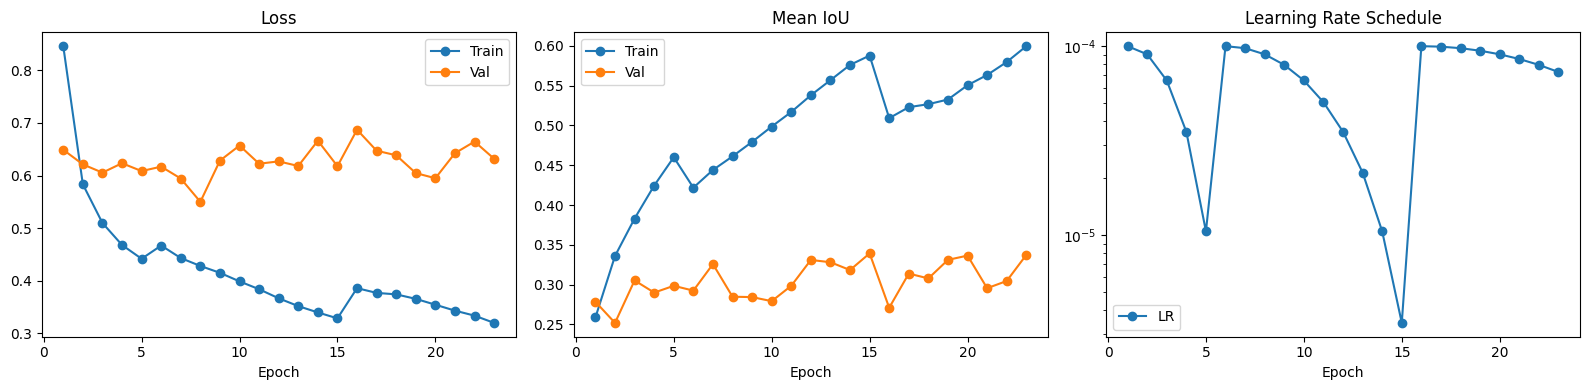

In [12]:
plot_train_history(history)

In [13]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES, siamese=True)

Test Loss: 1.5516
Test mIoU: 0.2271
Test Acc:  0.8634

Class                IoU     Prec   Recall
No Damage         0.8851   0.8998   0.9819
Minor             0.2185   0.4626   0.2928
Major             0.0185   0.1122   0.0217
Destroyed         0.0039   0.1595   0.0040
Unclassified      0.0096   0.0451   0.0120


In [ ]:
visualize_predictions(model=model, test_loader=test_loader, device=device,
    num_samples=5, title="Siamese U-Net Predictions")